# 03 · Boundary audit and the acceptance gate

## What this is

The gate that decides whether a completed preparation + equilibration is allowed
to feed production. It runs here against the **retained reference run**
(`project_1/preparation/` + `project_1/equilibration/`, July 15 2026) and
reproduces its numbers, so the notebook is both the procedure and its own
regression test.

## The four levels, and why each exists

| Level | Question | Catches |
|---|---|---|
| 1 · Preparation completion | did the chemistry actually finish? | silent SQM non-convergence, tLEaP errors, wrong ligand charge |
| 2 · Executed protocol length | did every stage run its full schedule? | truncated stages, wrong report interval, missing ghost lines |
| 3 · Thermodynamic behaviour | is the trace physical, not just finite at the end? | slow blow-ups, drift, volume excursions |
| 4 · Physical topology integrity | is the saved topology what the sampler thought it was? | leaked ghosts, discarded accepted waters, all-zero waters |

Level 4 is the one that matters most and the one that is easiest to skip: it
requires an **independent reload from disk** of every AMBER stage pair. The
July 2026 incident passed levels 1–3 and failed only level 4.

## Workflow

0. Configuration
1. Imports
2. Level 1 — preparation completion
3. Level 2 — executed protocol length
4. Level 3 — thermodynamic traces (with figures)
5. Level 4 — topology integrity and handoff arithmetic
6. Cross-stage force-field comparison
7. Verdict
8. Recap and the known-good benchmark table

---
## 0 · Configuration

In [1]:
from pathlib import Path

PROJECT_1 = Path("/home/moshe/intern_projects/project_1")

# ── The run under audit ───────────────────────────────────────────────────────
# Point these at any replica directory: <run>/preparation and <run>/equilibration.
PREP_DIR = PROJECT_1 / "preparation"
EQUIL_DIR = PROJECT_1 / "equilibration"
PROD_DIR = None                     # optional; set to <run>/production to audit it too

PREFIX = "CRY1AN139"
NUM_GHOSTS = 45
TARGET_TEMPERATURE_K = 300.0

# ── Expected schedule for the `full` profile ──────────────────────────────────
# Excluding headers. A mismatch here means the run is not the canonical schedule,
# whatever the directory is called.
EXPECTED = {
    "uvt1": dict(records=5,   first=100,   last=500,       ghost_lines=100),
    "npt":  dict(records=400, first=2_500, last=1_000_000, ghost_lines=0),
    "uvt2": dict(records=500, first=500,   last=250_000,   ghost_lines=125),
    "prod": dict(records=10_000, first=500, last=5_000_000, ghost_lines=2_500),
}

print(f"preparation  : {PREP_DIR}   (exists={PREP_DIR.is_dir()})")
print(f"equilibration: {EQUIL_DIR}  (exists={EQUIL_DIR.is_dir()})")
print(f"production   : {PROD_DIR}")

preparation  : /home/moshe/intern_projects/project_1/preparation   (exists=True)
equilibration: /home/moshe/intern_projects/project_1/equilibration  (exists=True)
production   : None


---
## 1 · Imports

In [2]:
import csv
import math
import statistics
from collections import Counter

import numpy as np

try:
    import matplotlib.pyplot as plt
    HAVE_MPL = True
except ImportError:
    HAVE_MPL = False
    print("matplotlib unavailable — figures will be skipped")

try:
    import parmed as pmd
    HAVE_PARMED = True
except ImportError:
    HAVE_PARMED = False
    print("parmed unavailable — level 4 will be skipped")

FINDINGS = []          # (level, severity, message); severity in {"ok","warn","fail"}


def record(level, severity, message):
    FINDINGS.append((level, severity, message))
    mark = {"ok": "  ok ", "warn": "  ~~ ", "fail": "  !! "}[severity]
    print(f"{mark}{message}")

---
## 2 · Level 1 — preparation completion

Three markers, all of which a broken preparation can pass silently without:

1. SQM reports `Calculation Completed` — AM1 converged, so the BCC charges mean
   something.
2. The requested ligand charge is recovered to within MOL2 rounding.
3. tLEaP's **final** line reports `Errors = 0`.

The `addIonsRand` same-sign warning is **expected**: the unsolvated complex is
+1, so tLEaP declines to add `Na+` and the following `Cl-` neutralises it. Do not
"fix" that warning.

In [3]:
# ── Level 1 ───────────────────────────────────────────────────────────────────
def mol2_atoms_and_charge(mol2: Path):
    total, atoms, in_atoms = 0.0, 0, False
    for line in mol2.read_text().splitlines():
        if line.startswith("@<TRIPOS>ATOM"):
            in_atoms = True
            continue
        if in_atoms and line.startswith("@<TRIPOS>"):
            break
        if in_atoms and line.strip():
            atoms += 1
            total += float(line.split()[-1])
    return atoms, total


print("LEVEL 1 — preparation completion")
print("─" * 78)

sqm_ok = False
for pattern in ("sqm.out", "*.out", "ANTECHAMBER_AM1BCC.AC"):
    for p in PREP_DIR.glob(pattern):
        if "Calculation Completed" in p.read_text(errors="ignore"):
            sqm_ok = True
            record(1, "ok", f"SQM 'Calculation Completed' found in {p.name}")
            break
    if sqm_ok:
        break
if not sqm_ok:
    record(1, "fail", "SQM 'Calculation Completed' marker NOT found")

mol2 = PREP_DIR / "AN139_protonated.mol2"
if mol2.is_file():
    n_atoms, q = mol2_atoms_and_charge(mol2)
    if abs(q) < 0.01:
        record(1, "ok", f"ligand MOL2: {n_atoms} atoms, net charge {q:+.6f} (near-integral 0)")
    else:
        record(1, "fail", f"ligand MOL2 net charge {q:+.6f} is not near-integral")
else:
    record(1, "fail", f"ligand MOL2 missing: {mol2}")

leap_log = PREP_DIR / "leap.log"
if leap_log.is_file():
    lines = leap_log.read_text(errors="ignore").splitlines()
    exiting = [l for l in lines if "Exiting LEaP" in l]
    added = [l for l in lines if "Added" in l and "residues" in l]
    samesign = [l for l in lines if "same sign" in l.lower()]
    if exiting:
        final = exiting[-1].strip()
        if "Errors = 0" in final:
            record(1, "ok", f"tLEaP final line: {final}")
        else:
            record(1, "fail", f"tLEaP reported errors: {final}")
    for l in added[-1:]:
        record(1, "ok", f"tLEaP {l.strip()}  (one water is later replaced by Cl-)")
    if samesign:
        record(1, "ok", "expected addIonsRand same-sign warning present "
                        "(complex is +1; the following Cl- neutralises it)")
    else:
        record(1, "warn", "no same-sign warning found — check the ion commands")
else:
    record(1, "fail", f"leap.log missing: {leap_log}")

LEVEL 1 — preparation completion
──────────────────────────────────────────────────────────────────────────────
  ok SQM 'Calculation Completed' found in sqm.out
  ok ligand MOL2: 59 atoms, net charge +0.000001 (near-integral 0)
  ok tLEaP final line: Exiting LEaP: Errors = 0; Warnings = 7; Notes = 1.
  ok tLEaP Added 18801 residues.  (one water is later replaced by Cl-)
  ok expected addIonsRand same-sign warning present (complex is +1; the following Cl- neutralises it)


---
## 3 · Level 2 — executed protocol length

Counted, not assumed. Every stage's CSV must have exactly the expected number of
records at exactly the expected step values, and every GCMC stage must have
exactly one ghost-state line per cycle.

One legitimate oddity: **an empty UVT2 Loch log is not by itself a failure.** The
CSV, the ghost record, stdout and the saved handoff are authoritative; the Loch
log is a convenience.

In [4]:
# ── Level 2 ───────────────────────────────────────────────────────────────────
def read_csv_steps(path: Path):
    rows = list(csv.DictReader(path.open()))
    if not rows:
        return rows, []
    key = list(rows[0])[0]
    return rows, [int(float(r[key])) for r in rows]


def ghost_line_count(path: Path):
    return sum(1 for line in path.read_text().splitlines() if line.strip())


CSV_PATHS = {
    "uvt1": EQUIL_DIR / f"{PREFIX}_data_uvt1.csv",
    "npt":  EQUIL_DIR / f"{PREFIX}_data_npt.csv",
    "uvt2": EQUIL_DIR / f"{PREFIX}_data_uvt2.csv",
}
GHOST_PATHS = {
    "uvt1": EQUIL_DIR / f"{PREFIX}_equilibration_uvt1_ghosts.txt",
    "uvt2": EQUIL_DIR / f"{PREFIX}_equilibration_uvt2_ghosts.txt",
}
if PROD_DIR is not None:
    CSV_PATHS["prod"] = Path(PROD_DIR) / f"{PREFIX}_data_prod.csv"
    GHOST_PATHS["prod"] = Path(PROD_DIR) / f"{PREFIX}-gcmc-ghosts.txt"

print("LEVEL 2 — executed protocol length")
print("─" * 78)

TRACES = {}
for stage, path in CSV_PATHS.items():
    want = EXPECTED[stage]
    if not path.is_file():
        record(2, "fail", f"{stage}: CSV missing ({path.name})")
        continue
    rows, steps = read_csv_steps(path)
    TRACES[stage] = rows
    parts = []
    ok = True
    if len(rows) == want["records"]:
        parts.append(f"{len(rows)} records")
    else:
        parts.append(f"{len(rows)} records (expected {want['records']})")
        ok = False
    if steps and steps[0] == want["first"] and steps[-1] == want["last"]:
        parts.append(f"steps {steps[0]:,}..{steps[-1]:,}")
    else:
        parts.append(f"steps {steps[0]:,}..{steps[-1]:,} "
                     f"(expected {want['first']:,}..{want['last']:,})")
        ok = False
    # The step sequence must be a clean arithmetic run at the report interval.
    if len(steps) > 1:
        deltas = set(np.diff(steps).tolist())
        if len(deltas) == 1:
            parts.append(f"interval {deltas.pop():,}")
        else:
            parts.append(f"IRREGULAR intervals {sorted(deltas)[:5]}")
            ok = False
    record(2, "ok" if ok else "fail", f"{stage:<5} CSV: " + ", ".join(parts))

for stage, path in GHOST_PATHS.items():
    want = EXPECTED[stage]["ghost_lines"]
    if not path.is_file():
        record(2, "fail", f"{stage}: ghost history missing ({path.name})")
        continue
    n = ghost_line_count(path)
    record(2, "ok" if n == want else "fail",
           f"{stage:<5} ghost lines: {n:,}" + ("" if n == want else f" (expected {want:,})"))

for stage in ("uvt1", "uvt2"):
    log = EQUIL_DIR / f"{PREFIX}_equilibration_{stage}.log"
    if log.is_file():
        size = log.stat().st_size
        if size == 0 and stage == "uvt2":
            record(2, "warn", "UVT2 Loch log is empty — NOT a failure on its own; "
                              "CSV/ghost/stdout/handoff are authoritative")
        else:
            record(2, "ok", f"{stage} Loch log present ({size:,} bytes)")

LEVEL 2 — executed protocol length
──────────────────────────────────────────────────────────────────────────────
  ok uvt1  CSV: 5 records, steps 100..500, interval 100
  ok npt   CSV: 400 records, steps 2,500..1,000,000, interval 2,500
  ok uvt2  CSV: 500 records, steps 500..250,000, interval 500
  ok uvt1  ghost lines: 100
  ok uvt2  ghost lines: 125
  ok uvt1 Loch log present (110 bytes)
  ~~ UVT2 Loch log is empty — NOT a failure on its own; CSV/ghost/stdout/handoff are authoritative


---
## 4 · Level 3 — thermodynamic behaviour

Every field must be finite, and the **trace** must be inspected, not just its
last row. A run can end at a plausible number after passing through a state it
should not have visited.

Stage-specific expectations:

- **UVT1** covers only 1 ps. A temperature below 300 K here is normal, not a
  failure — the reference run averages 208.6 K over its five records.
- **NPT** should reach 300 K quickly and hold a stable volume and density with no
  later drift or excursion. This is the only stage whose density is physical.
- **UVT2** should stay finite near 300 K.
- **UVT1/UVT2 density is not the physical density.** `CsvStateWriter` includes the
  masses of the 45 appended buffer waters while a sampler is live.

In [5]:
# ── Level 3 ───────────────────────────────────────────────────────────────────
print("LEVEL 3 — thermodynamic behaviour")
print("─" * 78)

FIELDS = ["potential_kj_mol", "kinetic_kj_mol", "temperature_K", "volume_nm3", "density_g_ml"]
STATS = {}

for stage, rows in TRACES.items():
    if not rows:
        continue
    series, nonfinite = {}, []
    for f in FIELDS:
        if f not in rows[0]:
            continue
        vals = [float(r[f]) for r in rows]
        if not all(math.isfinite(v) for v in vals):
            nonfinite.append(f)
        series[f] = vals
    STATS[stage] = series
    if nonfinite:
        record(3, "fail", f"{stage}: NON-FINITE fields {nonfinite}")
    else:
        record(3, "ok", f"{stage}: all {len(series)} numeric fields finite over {len(rows)} records")

W = 96
print("\n╔" + "═" * W + "╗")
print("║ " + f"{'TRACE SUMMARY':^{W - 1}}"[:W - 1] + "║")
print("╠" + "═" * W + "╣")
hdr = f"{'stage':<7}{'field':<20}{'mean':>14}{'sd':>12}{'min':>14}{'max':>14}"
print("║ " + hdr.ljust(W - 1) + "║")
print("╟" + "─" * W + "╢")
for stage, series in STATS.items():
    for f, vals in series.items():
        sd = statistics.pstdev(vals) if len(vals) > 1 else 0.0
        line = (f"{stage:<7}{f:<20}{statistics.mean(vals):>14.4f}{sd:>12.4f}"
                f"{min(vals):>14.4f}{max(vals):>14.4f}")
        print("║ " + line.ljust(W - 1) + "║")
    print("╟" + "─" * W + "╢")
print("╚" + "═" * W + "╝")

# Stage-specific judgements
if "npt" in STATS:
    t = STATS["npt"]["temperature_K"]
    d = STATS["npt"]["density_g_ml"]
    v = STATS["npt"]["volume_nm3"]
    mean_t, sd_t = statistics.mean(t), statistics.pstdev(t)
    if abs(mean_t - TARGET_TEMPERATURE_K) < 2.0 and sd_t < 5.0:
        record(3, "ok", f"NPT temperature {mean_t:.2f} +/- {sd_t:.2f} K at target {TARGET_TEMPERATURE_K:.0f} K")
    else:
        record(3, "fail", f"NPT temperature {mean_t:.2f} +/- {sd_t:.2f} K is off target")
    record(3, "ok", f"NPT density {statistics.mean(d):.4f} +/- {statistics.pstdev(d):.4f} g/mL "
                    "(this is the ONLY physical density in the run)")
    # Second-half drift: compare the two halves rather than only the endpoints.
    half = len(v) // 2
    drift = statistics.mean(v[half:]) - statistics.mean(v[:half])
    rel = abs(drift) / statistics.mean(v)
    record(3, "ok" if rel < 0.01 else "warn",
           f"NPT volume settles near {statistics.mean(v[half:]):.1f} nm3; "
           f"half-to-half drift {drift:+.2f} nm3 ({rel * 100:.2f}%)")

if "uvt1" in STATS:
    t1 = statistics.mean(STATS["uvt1"]["temperature_K"])
    record(3, "ok", f"UVT1 temperature {t1:.1f} K over a 1 ps segment "
                    "— below 300 K is EXPECTED here, not a failure")

if "uvt2" in STATS:
    t2 = STATS["uvt2"]["temperature_K"]
    record(3, "ok" if abs(statistics.mean(t2) - TARGET_TEMPERATURE_K) < 2.0 else "fail",
           f"UVT2 temperature {statistics.mean(t2):.2f} +/- {statistics.pstdev(t2):.2f} K")

LEVEL 3 — thermodynamic behaviour
──────────────────────────────────────────────────────────────────────────────
  ok uvt1: all 5 numeric fields finite over 5 records
  ok npt: all 5 numeric fields finite over 400 records
  ok uvt2: all 5 numeric fields finite over 500 records

╔════════════════════════════════════════════════════════════════════════════════════════════════╗
║                                          TRACE SUMMARY                                         ║
╠════════════════════════════════════════════════════════════════════════════════════════════════╣
║ stage  field                         mean          sd           min           max              ║
╟────────────────────────────────────────────────────────────────────────────────────────────────╢
║ uvt1   potential_kj_mol      -857029.5288  15149.4975  -879699.6642  -836457.1681              ║
║ uvt1   kinetic_kj_mol         114810.2541  13491.7073    93619.8375   131264.8632              ║
║ uvt1   temperature_K      

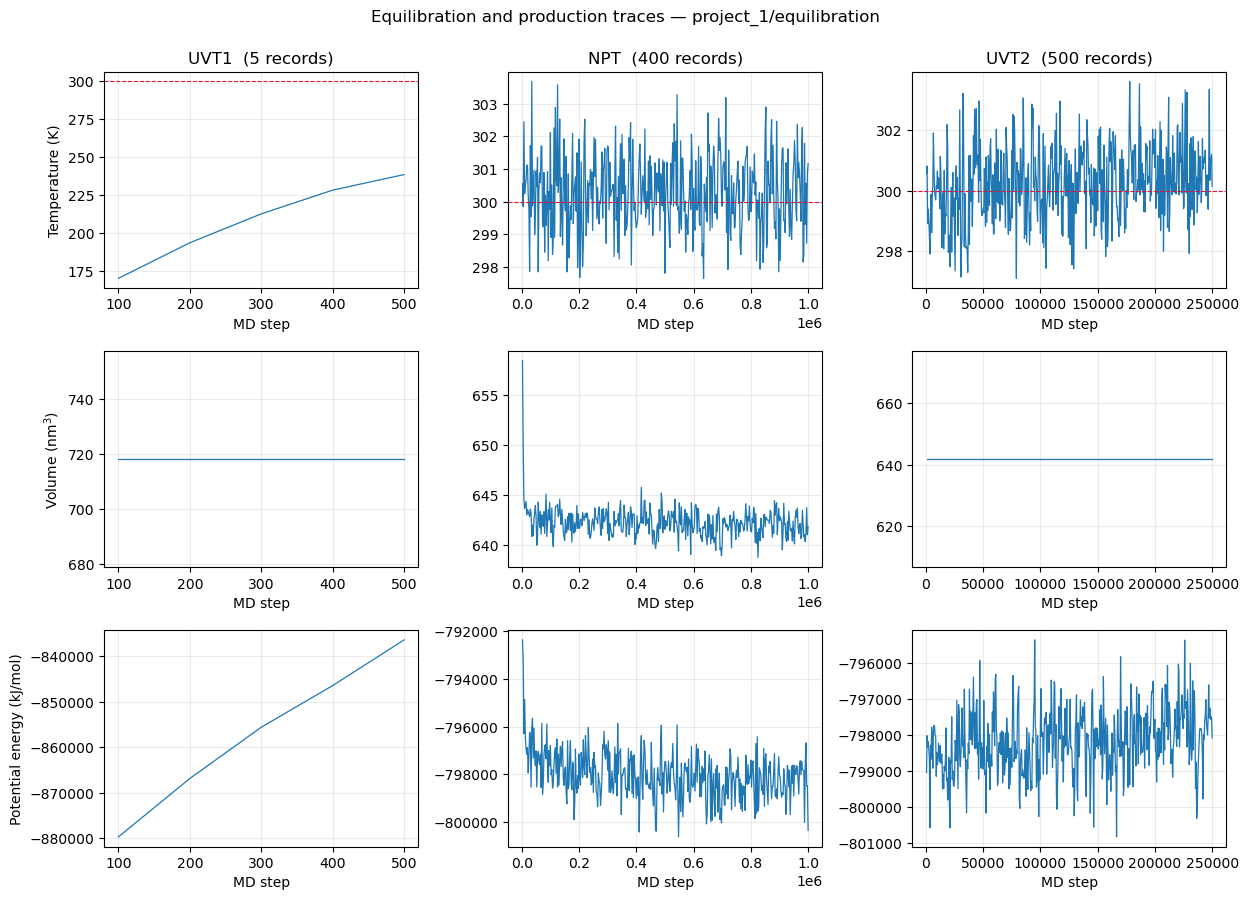

In [6]:
# ── Figure 1 — equilibration traces ──────────────────────────────────────────
if HAVE_MPL and STATS:
    stages = [s for s in ("uvt1", "npt", "uvt2", "prod") if s in STATS]
    panels = [("temperature_K", "Temperature (K)"),
              ("volume_nm3", "Volume (nm$^3$)"),
              ("potential_kj_mol", "Potential energy (kJ/mol)")]
    fig, axes = plt.subplots(len(panels), len(stages),
                             figsize=(4.2 * len(stages), 3.0 * len(panels)),
                             squeeze=False)
    fig.suptitle("Equilibration and production traces — "
                 f"{EQUIL_DIR.parent.name}/{EQUIL_DIR.name}", y=0.995)
    for col, stage in enumerate(stages):
        steps = [int(float(r[list(r)[0]])) for r in TRACES[stage]]
        for row, (field, label) in enumerate(panels):
            ax = axes[row][col]
            if field not in STATS[stage]:
                ax.set_axis_off()
                continue
            ax.plot(steps, STATS[stage][field], lw=0.9)
            if field == "temperature_K":
                ax.axhline(TARGET_TEMPERATURE_K, ls="--", lw=0.8, color="crimson")
            if row == 0:
                ax.set_title(f"{stage.upper()}  ({len(steps)} records)")
            if col == 0:
                ax.set_ylabel(label)
            ax.set_xlabel("MD step")
            ax.grid(alpha=0.25)
    fig.tight_layout()
    plt.show()
else:
    print("figure skipped")

  uvt1  inactive per report: mean 40.56  min 36  max 50  final 36  (100 reports)
  uvt2  inactive per report: mean 46.85  min 45  max 48  final 48  (125 reports)


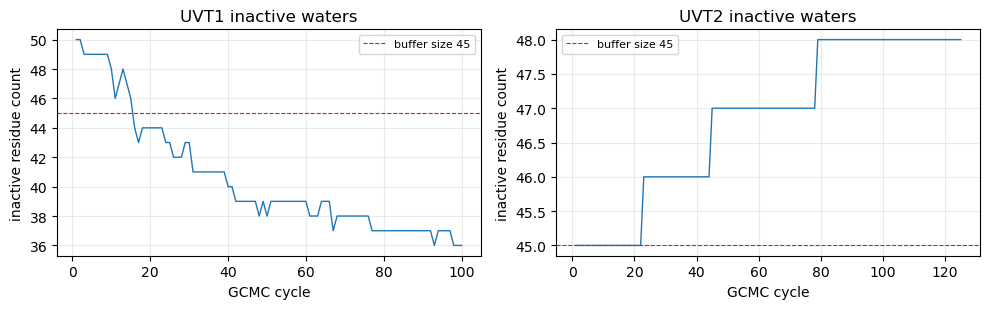


Reading this plot: the final value is the 'state-0 count' used in the handoff
arithmetic of level 5. A value BELOW 45 means some buffer waters were accepted;
a value ABOVE 45 means GCMC also deleted physical waters that were there before.



In [7]:
# ── Figure 2 — ghost-state history ───────────────────────────────────────────
# Each line of a ghost file is the comma-separated list of INACTIVE water residue
# IDs at that report. The count is not capped at 45: physical waters deleted by
# GCMC are inactive too, so it can exceed the buffer size.
def ghost_counts(path: Path):
    out = []
    for line in path.read_text().splitlines():
        line = line.strip().rstrip(",")
        if not line:
            continue
        out.append(len([x for x in line.split(",") if x.strip()]))
    return out


GHOSTS = {}
for stage, path in GHOST_PATHS.items():
    if path.is_file():
        GHOSTS[stage] = ghost_counts(path)

for stage, counts in GHOSTS.items():
    print(f"  {stage:<5} inactive per report: mean {statistics.mean(counts):.2f}  "
          f"min {min(counts)}  max {max(counts)}  final {counts[-1]}  "
          f"({len(counts)} reports)")

if HAVE_MPL and GHOSTS:
    fig, axes = plt.subplots(1, len(GHOSTS), figsize=(5.0 * len(GHOSTS), 3.2),
                             squeeze=False)
    for ax, (stage, counts) in zip(axes[0], GHOSTS.items()):
        ax.plot(range(1, len(counts) + 1), counts, lw=1.0)
        ax.axhline(NUM_GHOSTS, ls="--", lw=0.8, color="crimson",
                   label=f"buffer size {NUM_GHOSTS}")
        ax.set_title(f"{stage.upper()} inactive waters")
        ax.set_xlabel("GCMC cycle")
        ax.set_ylabel("inactive residue count")
        ax.legend(fontsize=8)
        ax.grid(alpha=0.25)
    fig.tight_layout()
    plt.show()

print("""
Reading this plot: the final value is the 'state-0 count' used in the handoff
arithmetic of level 5. A value BELOW 45 means some buffer waters were accepted;
a value ABOVE 45 means GCMC also deleted physical waters that were there before.
""")

---
## 5 · Level 4 — topology integrity and handoff arithmetic

Every AMBER pair is reloaded **independently from disk**. Two invariants:

**A. Zero all-zero waters.** No three-site water may have simultaneously zero
charge on all atoms *and* zero LJ ε on all atoms. That combination is a leaked
ghost, and it is the exact signature of the July 2026 failure.

**B. Handoff arithmetic**, applied separately to UVT1 and UVT2:

```
saved physical waters = input physical waters + 45 − final state-0 count
```

NPT must additionally have the *same* physical-water count as UVT1 — it neither
creates nor destroys water.

In [8]:
# ── Level 4 ───────────────────────────────────────────────────────────────────
print("LEVEL 4 — physical topology integrity")
print("─" * 78)

STAGE_TOPS = {
    "preparation": PREP_DIR / f"{PREFIX}_solvated.prmtop",
    "uvt1":        EQUIL_DIR / f"{PREFIX}uvt1.prmtop",
    "npt":         EQUIL_DIR / f"{PREFIX}npt.prmtop",
    "uvt2":        EQUIL_DIR / f"{PREFIX}uvt2.prmtop",
}
if PROD_DIR is not None:
    STAGE_TOPS["production-final"] = Path(PROD_DIR) / f"{PREFIX}-production-final.prmtop"
    STAGE_TOPS["raw-ghosts"] = Path(PROD_DIR) / f"{PREFIX}-loch-ghosts.prmtop"


def audit_topology(path: Path):
    top = pmd.load_file(str(path))
    names = Counter(r.name for r in top.residues)
    waters = [r for r in top.residues if r.name in ("WAT", "HOH")]
    zero = [
        r for r in waters
        if len(r.atoms) == 3
        and all(abs(a.charge) < 1e-9 for a in r.atoms)
        and all(a.epsilon == 0.0 for a in r.atoms)
    ]
    solute = [a for a in top.atoms if a.residue.name not in ("WAT", "HOH", "Cl-", "Na+")]
    return {
        "atoms": len(top.atoms),
        "residues": len(top.residues),
        "waters": len(waters),
        "zero_interaction": len(zero),
        "ligand_atoms": sum(len(r.atoms) for r in top.residues if r.name == "LIG"),
        "ca": sum(1 for a in top.atoms if a.name == "CA" and a.residue.name != "LIG"),
        "charge": sum(a.charge for a in top.atoms),
        "solute_particles": len(solute),
        "bonds": len(top.bonds),
        "angles": len(top.angles),
        "nonzero_torsions": sum(1 for d in top.dihedrals if d.type is not None
                                and getattr(d.type, "phi_k", 0.0) != 0.0),
    }


AUDIT = {}
if HAVE_PARMED:
    for stage, path in STAGE_TOPS.items():
        if not path.is_file():
            record(4, "warn", f"{stage}: topology absent ({path.name})")
            continue
        AUDIT[stage] = audit_topology(path)

    W = 92
    print("\n╔" + "═" * W + "╗")
    print("║ " + f"{'INDEPENDENT AMBER RELOAD':^{W - 1}}"[:W - 1] + "║")
    print("╠" + "═" * W + "╣")
    hdr = f"{'stage':<18}{'atoms':>10}{'waters':>10}{'all-zero':>10}{'lig':>6}{'CA':>6}{'charge':>12}"
    print("║ " + hdr.ljust(W - 1) + "║")
    print("╟" + "─" * W + "╢")
    for stage, a in AUDIT.items():
        line = (f"{stage:<18}{a['atoms']:>10,}{a['waters']:>10,}{a['zero_interaction']:>10}"
                f"{a['ligand_atoms']:>6}{a['ca']:>6}{a['charge']:>+12.6f}")
        print("║ " + line.ljust(W - 1) + "║")
    print("╚" + "═" * W + "╝")

    # Invariant A — everywhere except the deliberately ghost-containing topology.
    for stage, a in AUDIT.items():
        if stage == "raw-ghosts":
            expect = NUM_GHOSTS
            ok = a["zero_interaction"] == expect
            record(4, "ok" if ok else "fail",
                   f"raw trajectory topology holds exactly {a['zero_interaction']} "
                   f"zero-interaction ghosts (expected {expect})")
        else:
            ok = a["zero_interaction"] == 0
            record(4, "ok" if ok else "fail",
                   f"{stage}: {a['zero_interaction']} all-zero charge/LJ waters "
                   "(must be 0 in a physical topology)")
else:
    print("  parmed unavailable — level 4 skipped")

LEVEL 4 — physical topology integrity
──────────────────────────────────────────────────────────────────────────────



╔════════════════════════════════════════════════════════════════════════════════════════════╗
║                                  INDEPENDENT AMBER RELOAD                                  ║
╠════════════════════════════════════════════════════════════════════════════════════════════╣
║ stage                  atoms    waters  all-zero   lig    CA      charge                   ║
╟────────────────────────────────────────────────────────────────────────────────────────────╢
║ preparation           64,109    18,800         0    59   476   +0.000001                   ║
║ uvt1                  64,136    18,809         0    59   476   +0.000001                   ║
║ npt                   64,136    18,809         0    59   476   +0.000001                   ║
║ uvt2                  64,127    18,806         0    59   476   +0.000001                   ║
╚════════════════════════════════════════════════════════════════════════════════════════════╝
  ok preparation: 0 all-zero charge/LJ waters (mu

In [9]:
# ── Invariant B — handoff arithmetic ─────────────────────────────────────────
print("\nHANDOFF ARITHMETIC")
print("─" * 78)


def final_state_zero(stage):
    counts = GHOSTS.get(stage)
    return counts[-1] if counts else None


if AUDIT:
    chain = [
        ("UVT1", "preparation", "uvt1", "uvt1"),
        ("UVT2", "npt", "uvt2", "uvt2"),
    ]
    for label, src, dst, ghost_stage in chain:
        if src not in AUDIT or dst not in AUDIT:
            record(4, "warn", f"{label}: cannot check, missing {src} or {dst}")
            continue
        n_in = AUDIT[src]["waters"]
        n_out = AUDIT[dst]["waters"]
        s0 = final_state_zero(ghost_stage)
        if s0 is None:
            record(4, "warn", f"{label}: no ghost history, arithmetic not checkable")
            continue
        expected = n_in + NUM_GHOSTS - s0
        ok = expected == n_out
        record(4, "ok" if ok else "fail",
               f"{label}: {n_in:,} + {NUM_GHOSTS} - {s0} = {expected:,}  "
               f"vs saved {n_out:,}   net {n_out - n_in:+d}")

    if "uvt1" in AUDIT and "npt" in AUDIT:
        ok = AUDIT["uvt1"]["waters"] == AUDIT["npt"]["waters"]
        record(4, "ok" if ok else "fail",
               f"NPT conserves water count: {AUDIT['uvt1']['waters']:,} -> "
               f"{AUDIT['npt']['waters']:,}")

    for stage, a in AUDIT.items():
        if stage == "raw-ghosts":
            continue
        ok = abs(a["charge"]) < 1e-3
        record(4, "ok" if ok else "fail",
               f"{stage}: net charge {a['charge']:+.6f} (neutral within rounding)")


HANDOFF ARITHMETIC
──────────────────────────────────────────────────────────────────────────────
  ok UVT1: 18,800 + 45 - 36 = 18,809  vs saved 18,809   net +9
  ok UVT2: 18,809 + 45 - 48 = 18,806  vs saved 18,806   net -3
  ok NPT conserves water count: 18,809 -> 18,809
  ok preparation: net charge +0.000001 (neutral within rounding)
  ok uvt1: net charge +0.000001 (neutral within rounding)
  ok npt: net charge +0.000001 (neutral within rounding)
  ok uvt2: net charge +0.000001 (neutral within rounding)


---
## 6 · Cross-stage force-field comparison

Residue and atom names agreeing is not enough. Compare the **solute** force-field
content across every stage: particle count, bonds, angles, nonzero torsions.

Two acceptable differences:

- Sire may omit zero-force torsion records. That does not change the potential,
  which is why the comparison counts *nonzero* torsions.
- Negligible serialization roundoff.

A changed **nonzero** parameter is not acceptable.

In [10]:
# ── Solute force-field fingerprint across stages ─────────────────────────────
if AUDIT:
    # Solute invariants: these must not move between stages.
    INVARIANT = ("solute_particles", "ligand_atoms", "ca", "nonzero_torsions", "angles")
    # Whole-system counts: these legitimately track the water count.
    SYSTEMWIDE = ("waters", "bonds")

    cols = INVARIANT + SYSTEMWIDE
    W = 104
    print("╔" + "═" * W + "╗")
    print("║ " + f"{'FORCE-FIELD COUNTS BY STAGE':^{W - 1}}"[:W - 1] + "║")
    print("╠" + "═" * W + "╣")
    print("║ " + ("  <- solute invariants ->".ljust(62)
                  + "<- whole system ->").ljust(W - 1) + "║")
    hdr = f"{'stage':<14}" + "".join(f"{k[:14]:>13}" for k in cols)
    print("║ " + hdr.ljust(W - 1) + "║")
    print("╟" + "─" * W + "╢")
    for stage, a in AUDIT.items():
        line = f"{stage:<14}" + "".join(f"{a[k]:>13,}" for k in cols)
        print("║ " + line.ljust(W - 1) + "║")
    print("╚" + "═" * W + "╝")

    ref_stage = "preparation" if "preparation" in AUDIT else next(iter(AUDIT))
    ref = AUDIT[ref_stage]
    for stage, a in AUDIT.items():
        if stage == "raw-ghosts":
            continue
        diff = {k: (ref[k], a[k]) for k in INVARIANT if ref[k] != a[k]}
        record(6, "fail" if diff else "ok",
               f"{stage}: solute invariants {'DIFFER from ' + ref_stage + ': ' + str(diff) if diff else 'identical to ' + ref_stage}")

    # The whole-system bond count should move by exactly 3 per water added or
    # removed (TIP3P carries two O-H bonds plus the H-H term). If it does not,
    # something other than water changed.
    for stage, a in AUDIT.items():
        if stage in ("raw-ghosts", ref_stage):
            continue
        d_water = a["waters"] - ref["waters"]
        d_bonds = a["bonds"] - ref["bonds"]
        ok = d_bonds == 3 * d_water
        record(6, "ok" if ok else "fail",
               f"{stage}: {d_water:+d} waters vs {ref_stage} -> {d_bonds:+d} bonds "
               f"({'exactly 3 per water' if ok else 'NOT 3 per water — non-water change'})")

    print("""
  Reading this: solute_particles / ligand_atoms / CA / nonzero_torsions / angles
  are the invariants — they must be byte-identical across every stage. waters and
  bonds are whole-system and are SUPPOSED to move, by exactly 3 bonds per water.

  Sire may omit zero-force torsion records, which is why only NONZERO torsions
  are compared; that omission does not change the potential. Negligible
  serialization roundoff is acceptable, a changed nonzero parameter is not.

  The pipeline auditor goes further than this notebook and compares mass, charge,
  LJ and exclusions/1-4 exceptions per solute atom.
""")

╔════════════════════════════════════════════════════════════════════════════════════════════════════════╗
║                                       FORCE-FIELD COUNTS BY STAGE                                      ║
╠════════════════════════════════════════════════════════════════════════════════════════════════════════╣
║   <- solute invariants ->                                     <- whole system ->                       ║
║ stage         solute_particl ligand_atoms           canonzero_torsio       angles       waters        bonds║
╟────────────────────────────────────────────────────────────────────────────────────────────────────────╢
║ preparation           7,708           59          476       26,203       14,121       18,800       64,217║
║ uvt1                  7,708           59          476       26,203       14,121       18,809       64,244║
║ npt                   7,708           59          476       26,203       14,121       18,809       64,244║
║ uvt2                  7,7

---
## 7 · Verdict

In [11]:
# ── Verdict ───────────────────────────────────────────────────────────────────
from collections import defaultdict

by_level = defaultdict(lambda: {"ok": 0, "warn": 0, "fail": 0})
for level, sev, _ in FINDINGS:
    by_level[level][sev] += 1

W = 66
print("╔" + "═" * W + "╗")
print("║ " + f"{'ACCEPTANCE GATE VERDICT':^{W - 1}}"[:W - 1] + "║")
print("╠" + "═" * W + "╣")
LEVEL_NAMES = {1: "preparation completion", 2: "executed protocol length",
               3: "thermodynamic behaviour", 4: "topology integrity",
               6: "cross-stage force field"}
for level in sorted(by_level):
    c = by_level[level]
    line = (f"level {level}  {LEVEL_NAMES.get(level, ''):<26}"
            f"ok {c['ok']:>3}   warn {c['warn']:>3}   FAIL {c['fail']:>3}")
    print("║ " + line.ljust(W - 1) + "║")
print("╟" + "─" * W + "╢")
total_fail = sum(c["fail"] for c in by_level.values())
total_warn = sum(c["warn"] for c in by_level.values())
verdict = ("PRODUCTION-READY" if total_fail == 0
           else f"BLOCKED — {total_fail} failing check(s)")
print("║ " + f"{verdict:^{W - 1}}"[:W - 1] + "║")
print("╚" + "═" * W + "╝")

if total_fail:
    print("\nFAILURES")
    for level, sev, msg in FINDINGS:
        if sev == "fail":
            print(f"  L{level}  {msg}")
if total_warn:
    print("\nWARNINGS (review, not necessarily blocking)")
    for level, sev, msg in FINDINGS:
        if sev == "warn":
            print(f"  L{level}  {msg}")

╔══════════════════════════════════════════════════════════════════╗
║                      ACCEPTANCE GATE VERDICT                     ║
╠══════════════════════════════════════════════════════════════════╣
║ level 1  preparation completion    ok   5   warn   0   FAIL   0  ║
║ level 2  executed protocol length  ok   6   warn   1   FAIL   0  ║
║ level 3  thermodynamic behaviour   ok   8   warn   0   FAIL   0  ║
║ level 4  topology integrity        ok  11   warn   0   FAIL   0  ║
║ level 6  cross-stage force field   ok   7   warn   0   FAIL   0  ║
╟──────────────────────────────────────────────────────────────────╢
║                         PRODUCTION-READY                         ║
╚══════════════════════════════════════════════════════════════════╝

WARNINGS (review, not necessarily blocking)
  L2  UVT2 Loch log is empty — NOT a failure on its own; CSV/ghost/stdout/handoff are authoritative


---
## 8 · Recap and the known-good benchmark

The July 15 2026 full CRY1 run is a **regression benchmark, not an acceptance
target**. Water counts and acceptance histories are stochastic; topology
invariants, report counts and operation order are not.

| Boundary or trace | Observed |
|---|---|
| Prepared AMBER | 64,109 atoms · 18,800 waters · zero all-zero waters |
| UVT1 handoff | 18,809 waters · final state-0 = 36 · net **+9** · zero all-zero |
| NPT handoff | 18,809 waters · zero all-zero |
| UVT2 handoff | 64,127 atoms · 18,806 waters · final state-0 = 48 · net **−3** · zero all-zero |
| NPT trace | 300.29 ± 1.15 K · 1.0185 ± 0.0024 g/mL · volume near 642 nm³ |
| UVT2 trace | 300.24 ± 1.22 K · finite through 250,000 MD steps |

### Interpreting a failure

| Symptom | Most likely layer |
|---|---|
| `handoff_contains_zero_interaction_waters` | Sire topology materialization or save/reload. **Do not run NPT.** |
| Water arithmetic off, everything else clean | accepted waters discarded, or inactive ghosts leaked |
| CSV record count short, Slurm exited 0 | stage truncated — trust the artefact, not the exit status |
| Non-finite fields mid-trace but finite at the end | a visited state that should not have been; inspect the trace |
| UVT1 below 300 K | expected over a 1 ps segment; not a finding |
| UVT1/UVT2 density ≠ 1.0 g/mL | expected; buffer-water mass is included. Use NPT. |

### Cross-system additions for a ported run

For a system other than CRY1–AN139, additionally require:

- the audit JSON to state its scope explicitly — `smoke_plumbing_only`,
  `full_ludovic_schedule`, or `full_simulation_approximate_postprocessing`;
- checkpoint markers to hash source/protocol/runtime identity **and** every
  required output, with paths resolved inside the marker's own stage directory;
- ghost IDs to be free of duplicates, negatives, out-of-range values and
  non-water residues;
- for postprocessing: copied-topology hash, processed DCD frame/atom counts,
  finite coordinates, sphere model count, cluster-record count, and
  marker/metrics agreement.

Never validate a requested marker count against itself. Compare it with an
independent profile table.

**Next:** notebook 04 postprocesses the production trajectory and compares water
clusters across replicas.